Team ID :-  PTID-CDS-NOV-25-3295

Project ID :-  PRCP-1020-HousePricePred

The objective of this project is to identify the **best-performing machine learning
model for predicting house prices** using the Ames Houseing Dataset. Multiple regression models were trained, evaluated, and compared using key performance metrics sucj as **MAE, RMSE, and R^2 score**

Our goal is to select the most suitable model for deployment, ensuring high prediction accuracy, low error, and stable performance

Domain Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import joblib

import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
data = pd.read_csv('data.csv')
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
data.duplicated().sum()

0

### Descriptive Statistic

In [6]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## Missing value

In [7]:
missing_data = data.isnull().sum()
missing_data

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [8]:
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
# missing_percentage = ((data.isnull().sum() / len(data)) * 100).sort_values(ascending = False)
missing_percentage = ((data.isnull().sum() / len(data)) * 100)
missing_percentage
missing_info = pd.DataFrame({
    'Missing COunt' : missing_data,
    'Missing Percentage' : missing_percentage
})

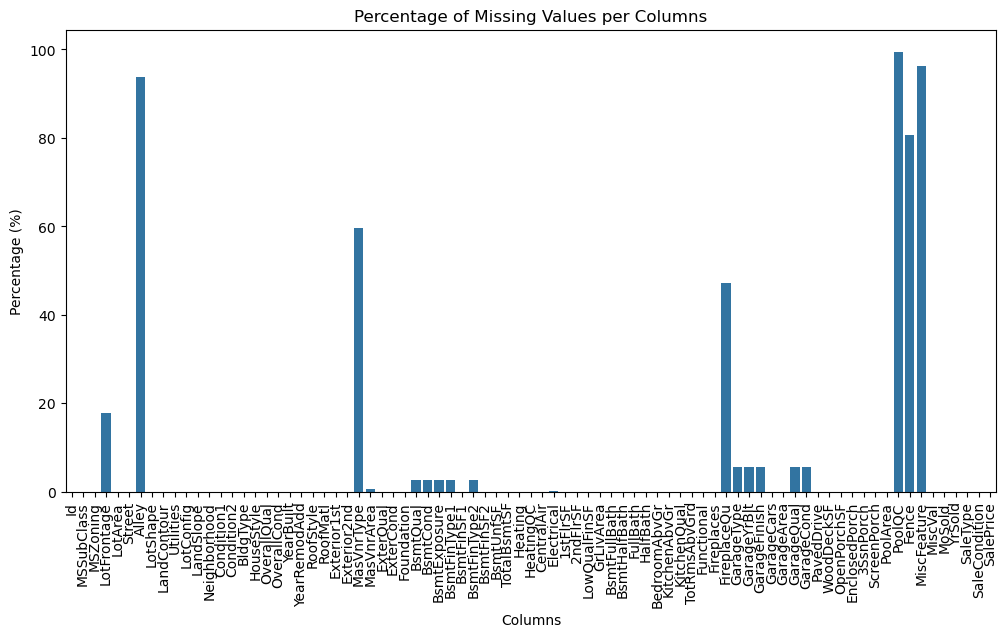

In [9]:

# print(missing_info)

plt.figure(figsize=(12,6))
sns.barplot(x = missing_percentage.index, y = missing_percentage)
plt.xticks(rotation = 90)
plt.title('Percentage of Missing Values per Columns')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')
plt.show()

### Insight about missing value

* Columns like PoolQC, MiscFeature, Fence, and Alley have very high percentage of missing values ( over 80 - 90 %).

### Analyzing Target Variable : SalePrice

In [10]:
data['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

### statistic of SalePrice
* Min : 34,000
* Max : 755,000
* Mean : 180,921
* Median : 163,000
* Std Dev : 79,442

### Univariate Analysis : Target Variable

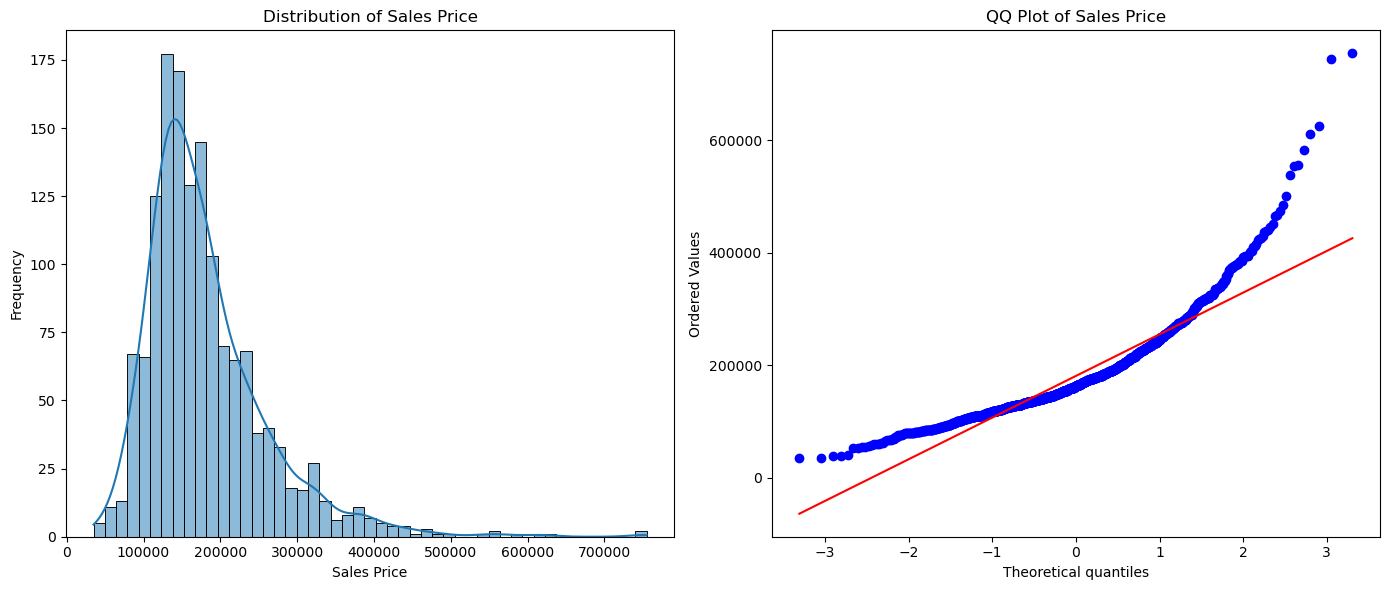

In [11]:
#skipping
from scipy import stats
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.histplot(data['SalePrice'], kde = True)
plt.title('Distribution of Sales Price')
plt.xlabel('Sales Price')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
stats.probplot(data['SalePrice'], dist="norm", plot=plt)
plt.title('QQ Plot of Sales Price')
plt.tight_layout()
plt.show()

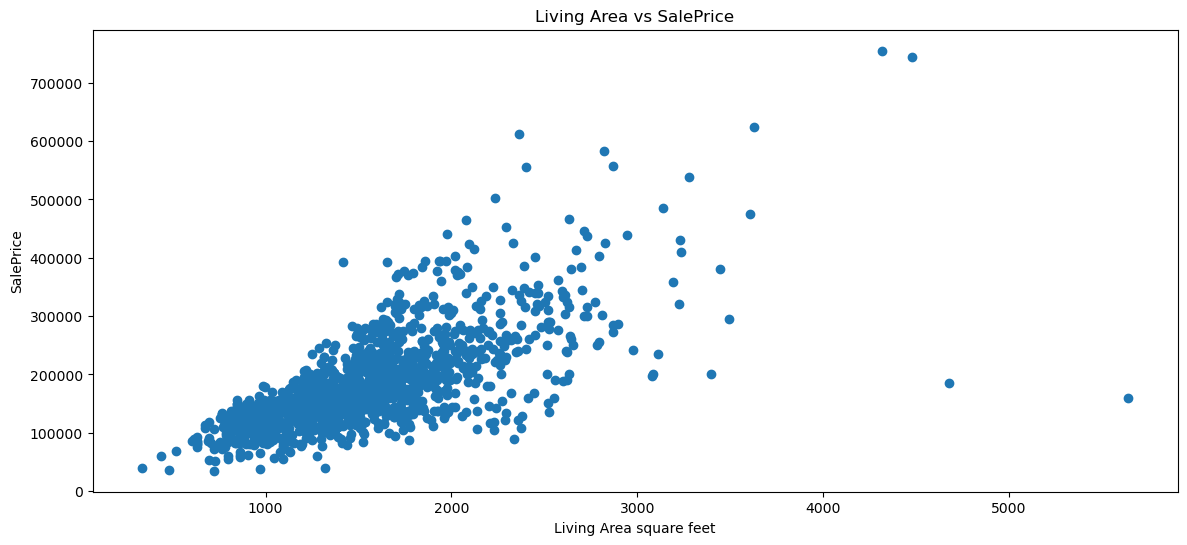

In [12]:
plt.figure(figsize=(14,6))
# plt.subplot(1,2,1)
plt.scatter(x = data['GrLivArea'], y = data['SalePrice'])
plt.title('Living Area vs SalePrice')
plt.ylabel('SalePrice')
plt.xlabel('Living Area square feet')
plt.show()

### CONtiniue from here 

In [13]:
# checking changes in value has applied in data
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [14]:
# sns.heatmap(correlation_matrix.corr(), annot=True)

In [15]:
# numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
# corr_with_target = data[numeric_cols].corr()["SalePrice"].abs().sort_values(ascending=False)
# top_corr = corr_with_target.drop("SalePrice").head(15)
# display_dataframe_to_user("Top 15 numeric features by absolute correlation with SalePrice", top_corr.reset_index().rename(columns={"index":"feature","SalePrice":"abs_corr"}))


# from caas_jupyter_tools import display_dataframe_to_user
col_numerica = data.select_dtypes(include= [np.number]).columns.tolist()
corr_with_target = data[col_numerica].corr()["SalePrice"].abs().sort_values(ascending=False)
top_corr = corr_with_target.drop("SalePrice")
display(top_corr.reset_index().rename(columns={"index": "feature", "SalePrice": "abs_corr"}))

# sns.heatmap(correlation_matrix.corr(), annot=True)

,feature,abs_corr
0,OverallQual,0.790982
1,GrLivArea,0.708624
2,GarageCars,0.640409
3,GarageArea,0.623431
4,TotalBsmtSF,0.613581
5,1stFlrSF,0.605852
6,FullBath,0.560664
7,TotRmsAbvGrd,0.533723
8,YearBuilt,0.522897
9,YearRemodAdd,0.507101


### Analysis in Numerical Features

In [16]:
numerical_cols = data.select_dtypes(include= ['int64','float64']).columns
numerical_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [17]:
selected_numerical_cols = numerical_cols.drop(['Id','SalePrice'])
selected_numerical_cols

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

* filling NaN value in numerical column

* checking which column has NaN value

In [18]:
# for columns in selected_numerical_cols:
#     if data[columns].isnu

data[selected_numerical_cols].isnull().sum()

MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
dtype: int64

In [19]:
for columns in selected_numerical_cols:
    if data[columns].isnull().sum()>0:
        data[columns].fillna(data[columns].median(), inplace=True)

* checking null value after filling null row with median value

In [20]:
data[selected_numerical_cols].isnull().sum()

MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
dtype: int64

### Univariate Analysis

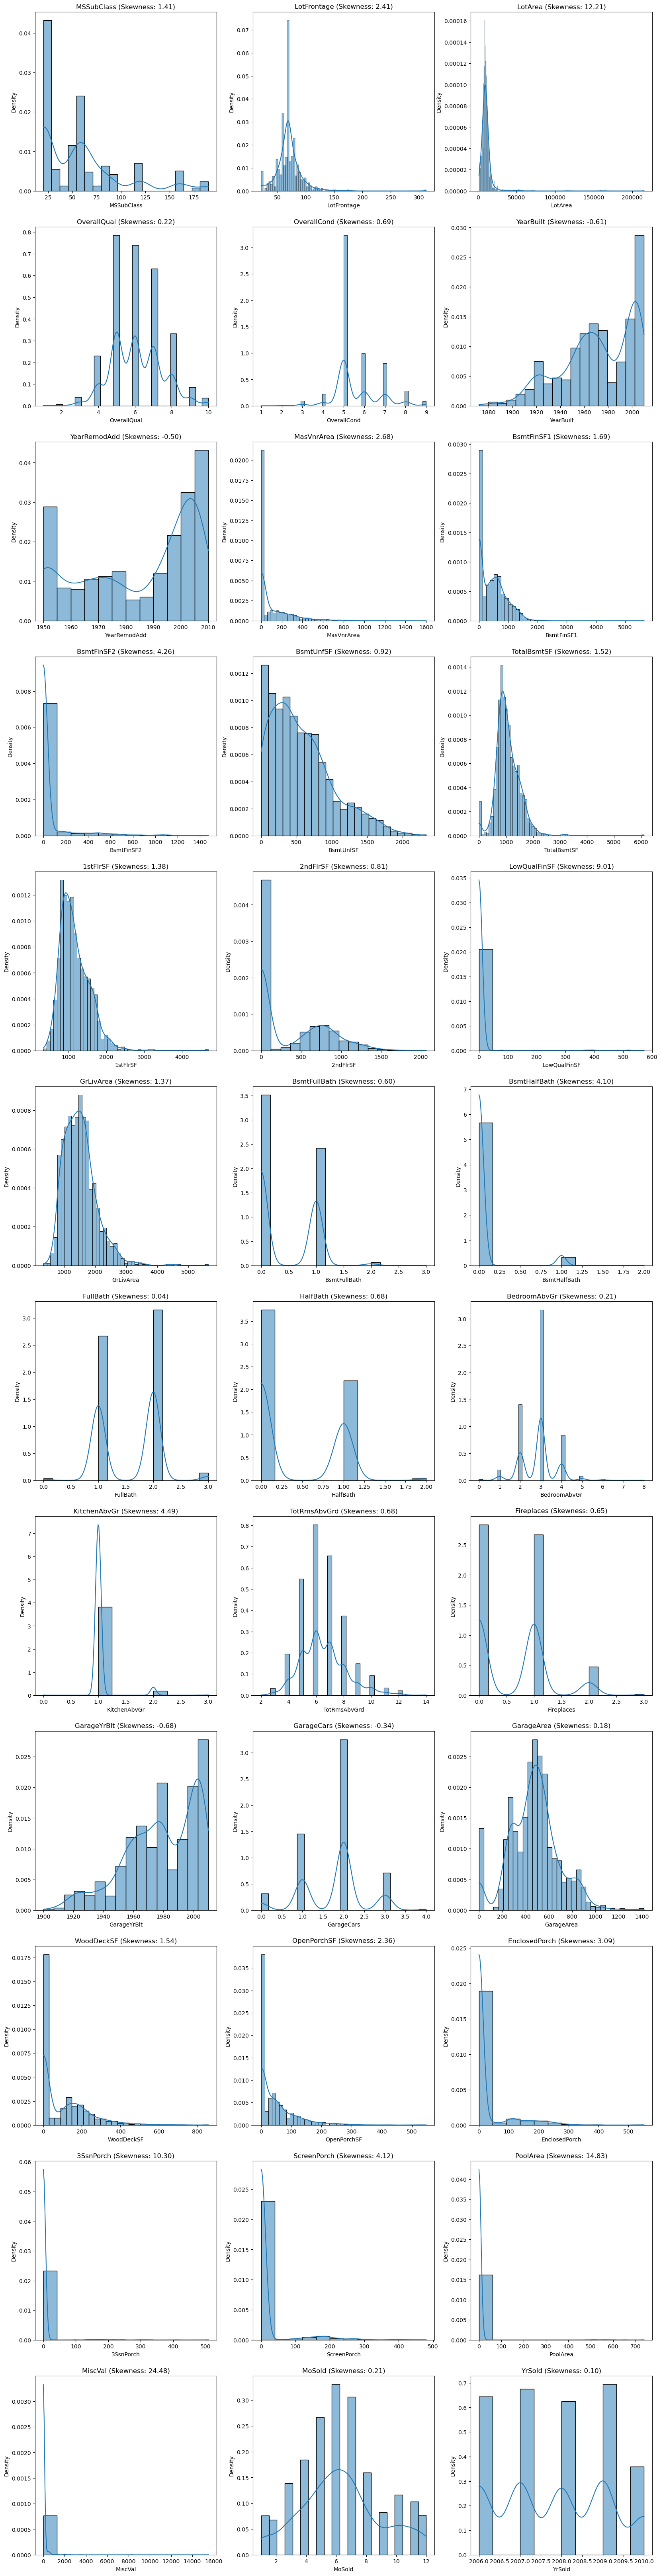

In [21]:

plt.figure(figsize=(20,90))

for i,col in enumerate(selected_numerical_cols):
    
    plt.subplot(13,3, i+1)
    sns.histplot(x=col, data=data, kde=True,stat = 'density')
    plt.title(f"{col} (Skewness: {data[col].skew():.2f})")


### Bivariate Analysis

Bivariate analysis helps identify relationships between features and the target variable.
Examples:
- Scatterplot: GrLivArea vs SalePrice
- Scatterplot: TotalBsmtSF vs SalePrice
- Boxplot: Neighborhood vs SalePrice
- Correlation values between individual features and SalePrice


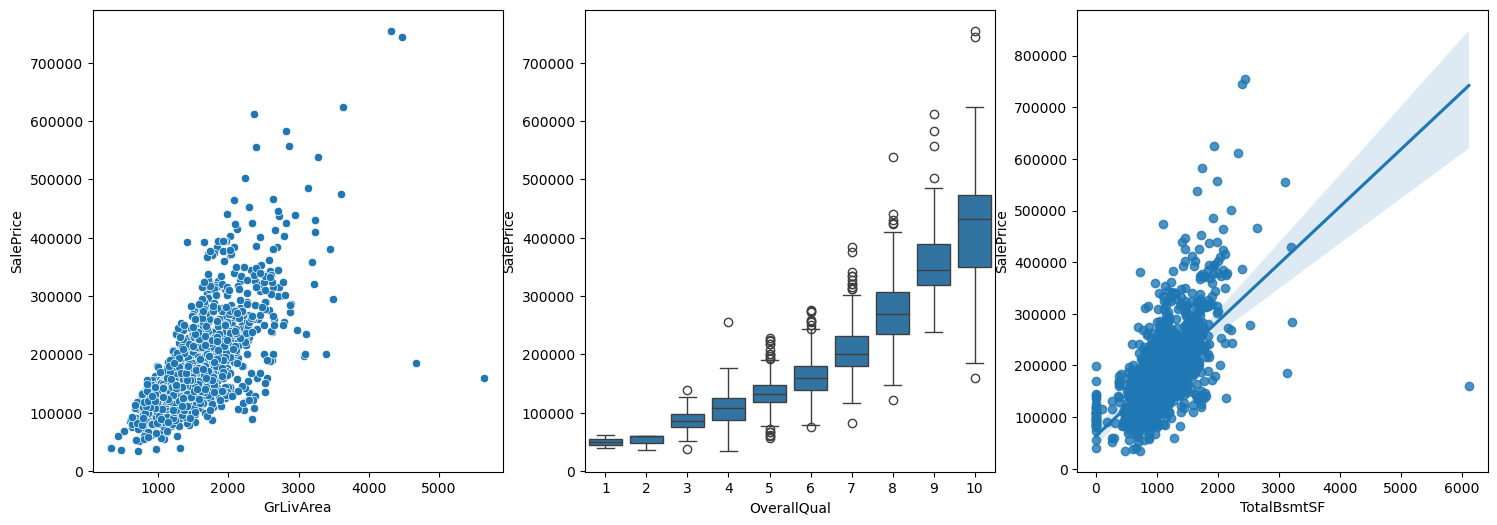

In [22]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
sns.scatterplot(x=data["GrLivArea"], y=data["SalePrice"])
plt.subplot(1,3,2)
sns.boxplot(x=data["OverallQual"], y=data["SalePrice"])
plt.subplot(1,3,3)
sns.regplot(x=data["TotalBsmtSF"], y=data["SalePrice"])
plt.show()

Text(0.5, 1.0, 'Correlation Matrix of key  Features')

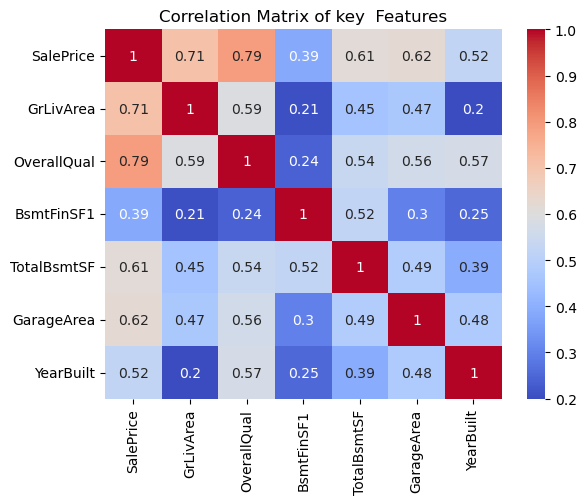

In [23]:
n_col = ['SalePrice','GrLivArea','OverallQual','BsmtFinSF1','TotalBsmtSF','GarageArea','YearBuilt']
correlation_matrix = data[n_col].corr()
sns.heatmap(correlation_matrix, annot=True,cmap='coolwarm')
plt.title('Correlation Matrix of key  Features')

1. GrLivArea vs SalePrice

* Strong positive relationship.
* Bigger living area = higher sale price.
* A few points far above cluster → outliers.

3. TotalBsmtSF vs SalePrice
* Clear positive trend.
* Homes with large basement areas tend to be more expensive.

4. GarageArea vs SalePrice

* Moderate positive trend.
* Larger garages contribute to slightly higher prices.

5. OverallQual vs SalePrice

* Very strong positive relationship.
* Higher quality rating strongly increases sale price.


### Multivariate Analysis

 Heatmap (Correlation)

* OverallQual, GrLivArea, TotalBsmtSF, GarageArea show the strongest correlation with SalePrice.
* Some numerical features are weakly related and may not impact the model heavily.

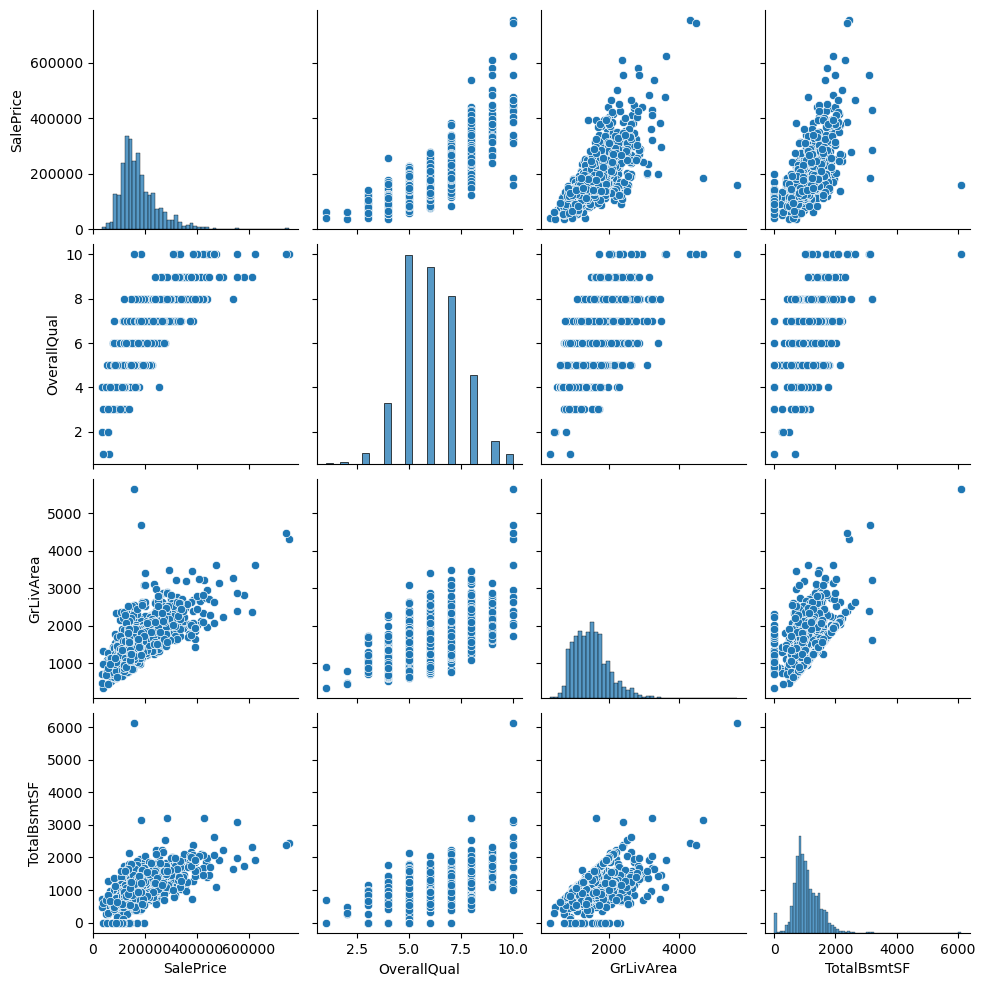

In [24]:
sns.pairplot(data[['SalePrice','OverallQual','GrLivArea','TotalBsmtSF']])


* Variables related to size (GrLivArea, TotalBsmtSF, GarageArea) cluster together.
* SalePrice increases with higher values across these features.

<Axes: xlabel='GrLivArea', ylabel='TotalBsmtSF'>

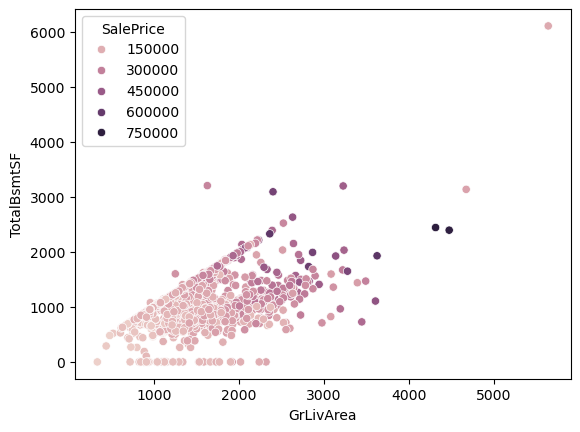

In [25]:
sns.scatterplot(
    x=data['GrLivArea'], 
    y=data['TotalBsmtSF'], 
    hue=data['SalePrice']
)


<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

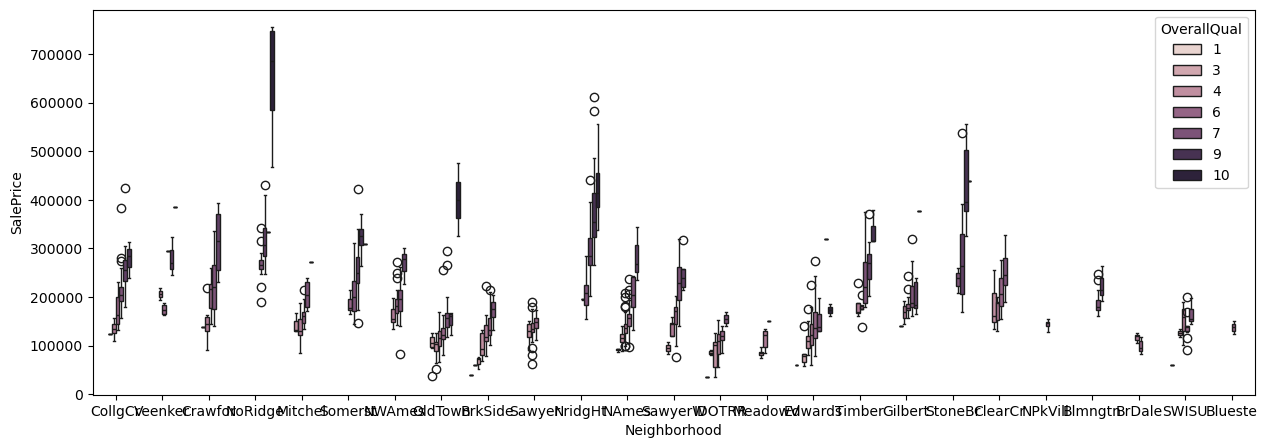

In [26]:
plt.figure(figsize=(15,5))
sns.boxplot(x='Neighborhood', y='SalePrice', hue='OverallQual', data=data)


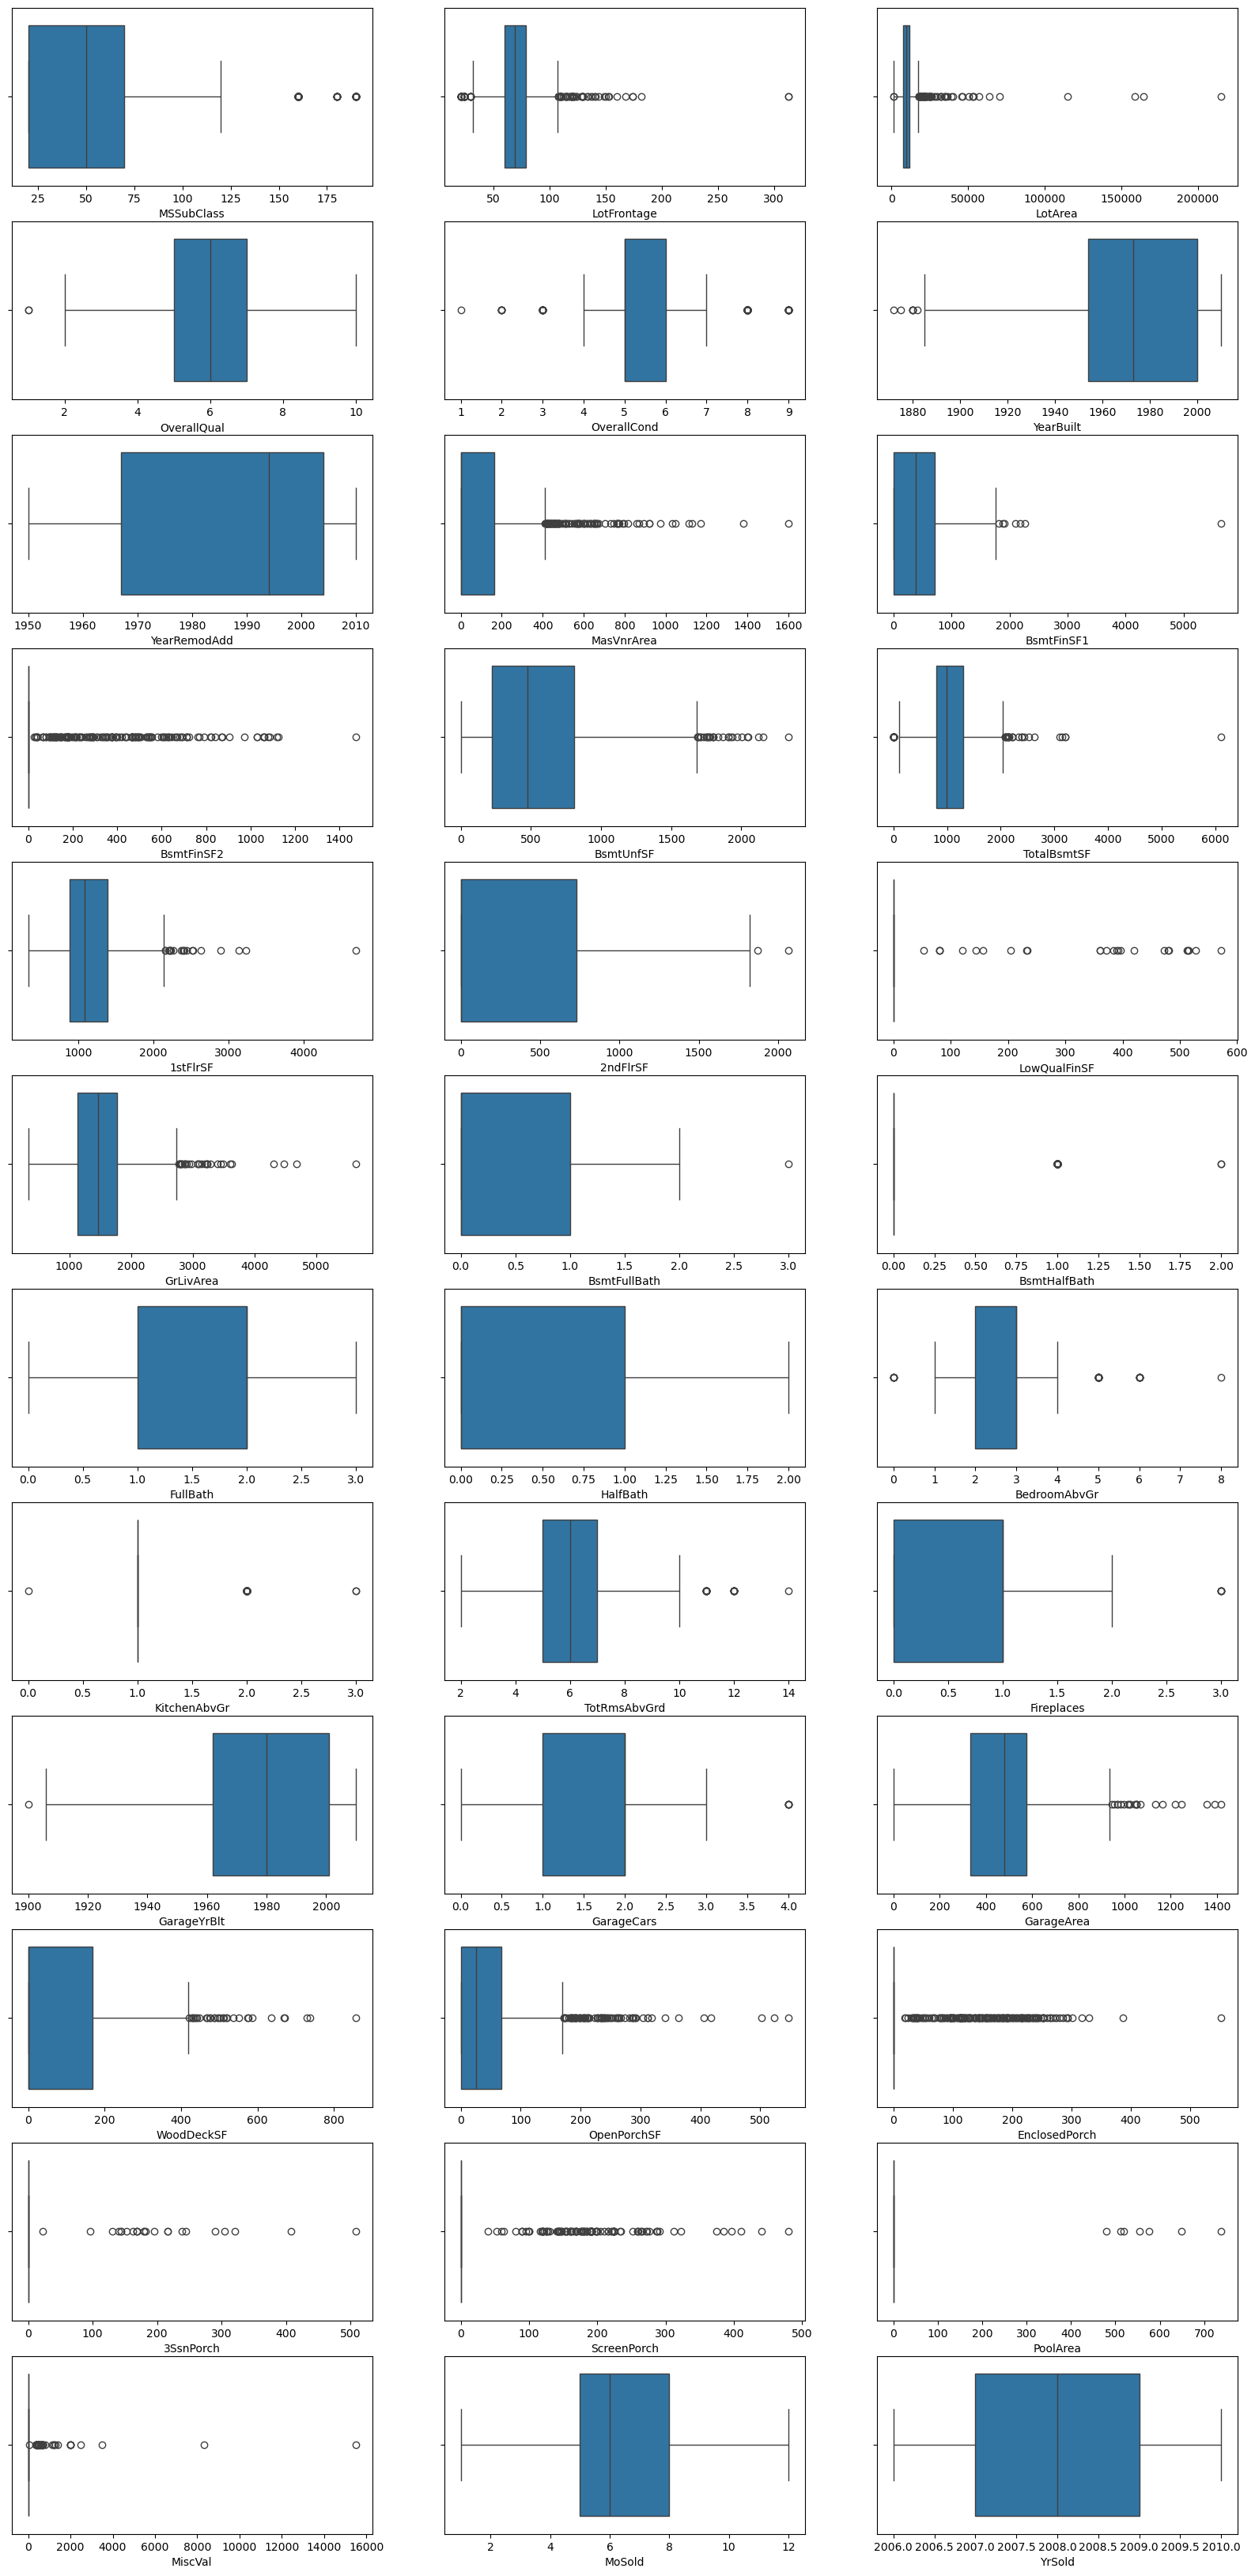

In [27]:
plt.figure(figsize=(20,45))
for i in enumerate(selected_numerical_cols):
    plt.subplot(13,3,i[0]+1)
    sns.boxplot(x=i[1], data=data)

# Handling Outlier

### LotArea

In [28]:
Q1 = data['LotArea'].quantile(0.25)
Q3 = data['LotArea'].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR

(7553.5, 11601.5, 4048.0)

In [29]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(1481.5, 17673.5)

<Axes: xlabel='LotArea'>

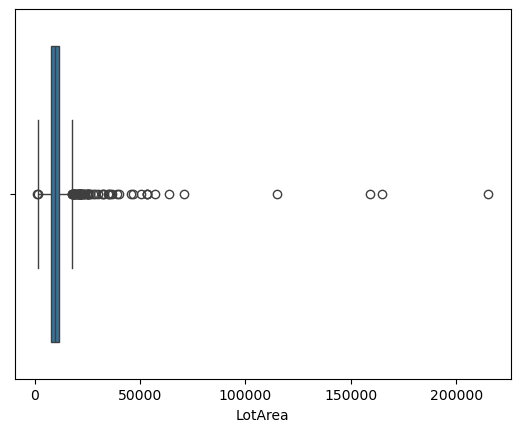

In [30]:
sns.boxplot(x=data['LotArea'])

In [31]:
count_extreme = (data['LotArea'] > 20000).sum()
count_extreme


53

In [32]:
median_value = data['LotArea'].median()
data['LotArea'] = data['LotArea'].apply(lambda x: median_value if x > 20001 else x)


<Axes: xlabel='LotArea'>

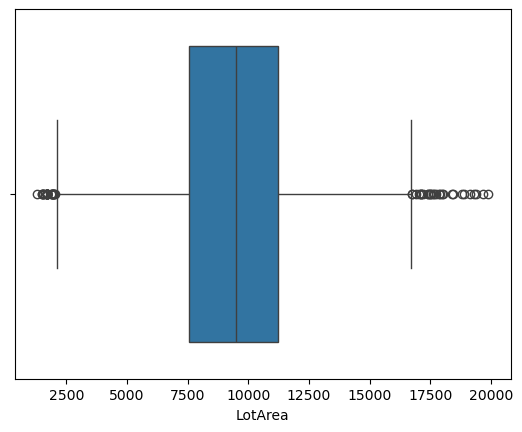

In [33]:
sns.boxplot(x=data['LotArea'])

### BsmtFinSF1

<Axes: xlabel='BsmtFinSF1'>

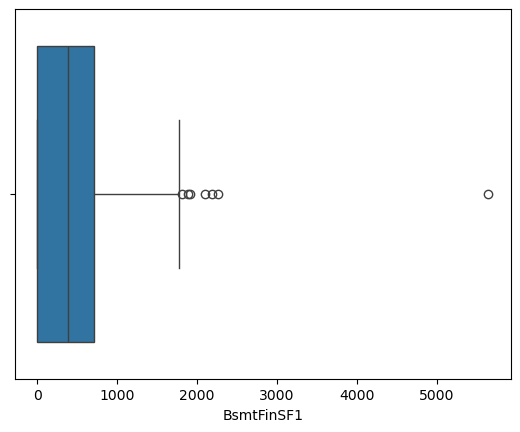

In [34]:
sns.boxplot(x= data['BsmtFinSF1'])


In [35]:
Q1 = data['BsmtFinSF1'].quantile(0.25)
Q3 = data['BsmtFinSF1'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound,Q1, Q3, IQR

(-1068.375, 1780.625, 0.0, 712.25, 712.25)

In [36]:
median_value = data['BsmtFinSF1'].median()
data['BsmtFinSF1'] = data['BsmtFinSF1'].apply(lambda x: median_value if x > 3001 else x)
count_extreme = (data['BsmtFinSF1'] > 50000).sum()
count_extreme


0

<Axes: xlabel='BsmtFinSF1'>

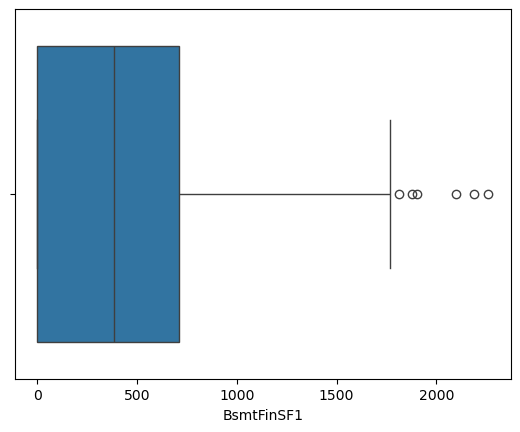

In [37]:
sns.boxplot(x= data['BsmtFinSF1'])


### TotalBsmnt

<Axes: xlabel='TotalBsmtSF'>

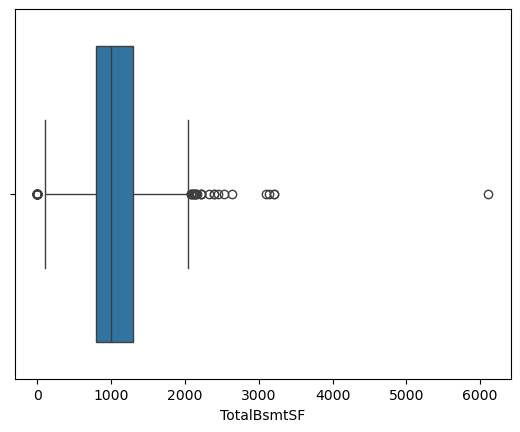

In [38]:
sns.boxplot(x= data['TotalBsmtSF'])


In [39]:
Q1 = data['TotalBsmtSF'].quantile(0.25)
Q3 = data['TotalBsmtSF'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound,Q1, Q3, IQR

(42.0, 2052.0, 795.75, 1298.25, 502.5)

In [40]:
count_extreme = (data['TotalBsmtSF'] > 2200).sum()
count_extreme


14

<Axes: xlabel='TotalBsmtSF'>

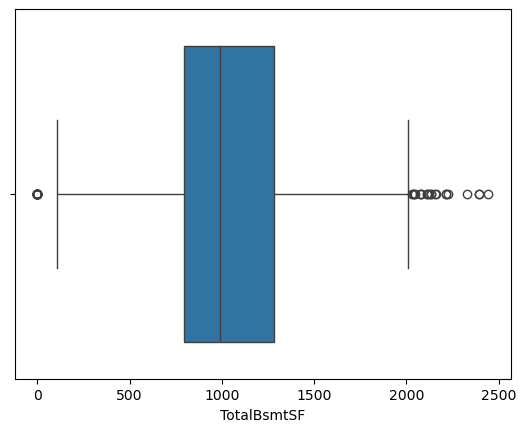

In [41]:
median_value = data['TotalBsmtSF'].median()
data['TotalBsmtSF'] = data['TotalBsmtSF'].apply(lambda x: median_value if x > 2501 else x)
sns.boxplot(x= data['TotalBsmtSF'])


### 1stFLr

In [42]:
Q1 = data['1stFlrSF'].quantile(0.25)
Q3 = data['1stFlrSF'].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR

(882.0, 1391.25, 509.25)

In [43]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(118.125, 2155.125)

<Axes: xlabel='1stFlrSF'>

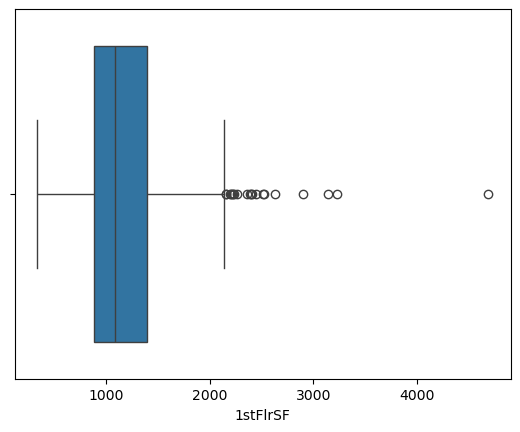

In [44]:
sns.boxplot(x=data['1stFlrSF'])

In [45]:
count_extreme = (data['1stFlrSF'] > 2300).sum()
count_extreme


12

In [46]:
median_value = data['1stFlrSF'].median()
data['1stFlrSF'] = data['1stFlrSF'].apply(lambda x: median_value if x > 2301 else x)


<Axes: xlabel='1stFlrSF'>

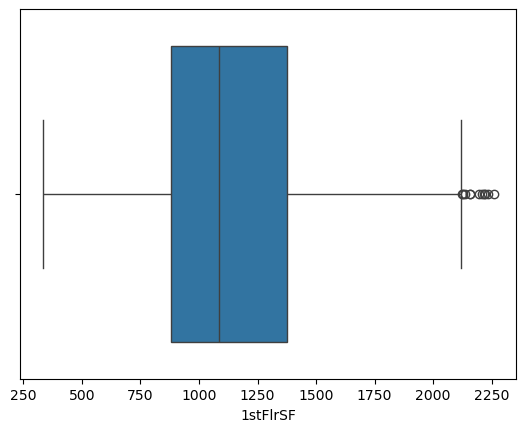

In [47]:
sns.boxplot(x=data['1stFlrSF'])

### GrLivArea

<Axes: xlabel='GrLivArea'>

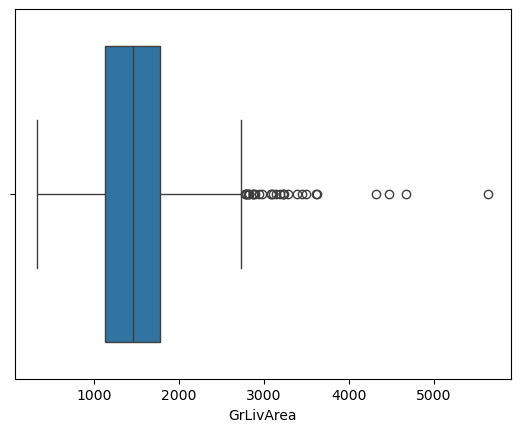

In [48]:
sns.boxplot(x=data['GrLivArea'])

In [49]:
Q1 = data['GrLivArea'].quantile(0.25)
Q3 = data['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
count_extreme = (data['GrLivArea'] > 3000).sum()


count_extreme,lower_bound, upper_bound, Q1, Q3, IQR

(18, 158.625, 2747.625, 1129.5, 1776.75, 647.25)

In [50]:
median_value = data['GrLivArea'].median()
data['GrLivArea'] = data['GrLivArea'].apply(lambda x: median_value if x > 3000 else x)


<Axes: xlabel='GrLivArea'>

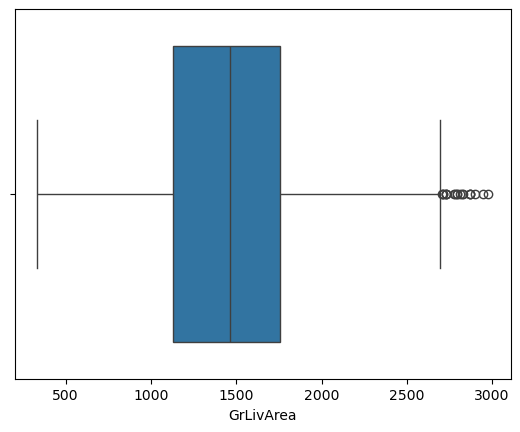

In [51]:
sns.boxplot(x=data['GrLivArea'])

In [52]:
data['PoolArea'].isnull().sum()

0

### creating Categorical Columns

In [53]:
categorical_col = data.select_dtypes(include = ['object']).columns.tolist()

In [54]:
print(selected_numerical_cols)
print('\n',categorical_col)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Fu

In [55]:
data.select_dtypes(include = ['object']).head(20)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,NaN,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,NaN,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
5,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,Wood,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
6,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,Stone,Gd,TA,PConc,Ex,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
7,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,Gable,CompShg,HdBoard,HdBoard,Stone,TA,TA,CBlock,Gd,TA,Mn,ALQ,BLQ,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,Shed,WD,Normal
8,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,Gable,CompShg,BrkFace,Wd Shng,NaN,TA,TA,BrkTil,TA,TA,No,Unf,Unf,GasA,Gd,Y,FuseF,TA,Min1,TA,Detchd,Unf,Fa,TA,Y,NaN,NaN,NaN,WD,Abnorml
9,RL,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,Gable,CompShg,MetalSd,MetalSd,NaN,TA,TA,BrkTil,TA,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,Gd,TA,Y,NaN,NaN,NaN,WD,Normal


* Categorical column have NaN value and need to replace with median

In [56]:
data[categorical_col].isnull().sum()

MSZoning            0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinType2       38
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
KitchenQual         0
Functional          0
FireplaceQu       690
GarageType         81
GarageFinish       81
GarageQual         81
GarageCond         81
PavedDrive          0
PoolQC           1453
Fence            1179
MiscFeature      1406
SaleType            0
SaleCondition       0
dtype: int64

In [57]:
for column in categorical_col:
    if data[column].isnull().sum() > 0:
        data[column].fillna('Unknown', inplace=True)



In [58]:
data[categorical_col].head(20)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,Unknown,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Unknown,Attchd,RFn,TA,TA,Y,Unknown,Unknown,Unknown,WD,Normal
1,RL,Pave,Unknown,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,Unknown,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,Unknown,Unknown,Unknown,WD,Normal
2,RL,Pave,Unknown,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,Unknown,Unknown,Unknown,WD,Normal
3,RL,Pave,Unknown,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,Unknown,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,Unknown,Unknown,Unknown,WD,Abnorml
4,RL,Pave,Unknown,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,Unknown,Unknown,Unknown,WD,Normal
5,RL,Pave,Unknown,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,Gable,CompShg,VinylSd,VinylSd,Unknown,TA,TA,Wood,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Unknown,Attchd,Unf,TA,TA,Y,Unknown,MnPrv,Shed,WD,Normal
6,RL,Pave,Unknown,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,Stone,Gd,TA,PConc,Ex,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,Unknown,Unknown,Unknown,WD,Normal
7,RL,Pave,Unknown,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,Gable,CompShg,HdBoard,HdBoard,Stone,TA,TA,CBlock,Gd,TA,Mn,ALQ,BLQ,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,Unknown,Unknown,Shed,WD,Normal
8,RM,Pave,Unknown,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,Gable,CompShg,BrkFace,Wd Shng,Unknown,TA,TA,BrkTil,TA,TA,No,Unf,Unf,GasA,Gd,Y,FuseF,TA,Min1,TA,Detchd,Unf,Fa,TA,Y,Unknown,Unknown,Unknown,WD,Abnorml
9,RL,Pave,Unknown,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,Gable,CompShg,MetalSd,MetalSd,Unknown,TA,TA,BrkTil,TA,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,Gd,TA,Y,Unknown,Unknown,Unknown,WD,Normal


In [59]:
# removing some column
selected_categorical_col = data[categorical_col].drop(['PoolQC','Fence','Alley','MiscFeature'], axis=1)


In [60]:
selected_categorical_col.head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Unknown,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,Unknown,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,Unknown,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [61]:
data['HouseAge'] = data['YrSold'] - data['YearBuilt']

In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   float64
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [63]:
(data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']).head()

0    2566.0
1    2524.0
2    2706.0
3    2473.0
4    3343.0
dtype: float64

In [64]:
data['RemodelAge'] = data['YrSold'] - data['YearRemodAdd']

In [65]:
data['TotalSurface'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

In [66]:
# print(" New Column : TotalSurface, RemodelAge, HouseAge")

### label encoding in categorical column

In [67]:
data_label_encod = data.copy()

In [68]:
from sklearn.preprocessing import LabelEncoder
label_encoder = {}

for i in selected_categorical_col:
    LE = LabelEncoder()
    data_label_encod[i] = LabelEncoder().fit_transform(data_label_encod[i].astype(str))
    label_encoder[i] = LE

In [69]:
#after label encoding 
selected_categorical_col.head()

# this show categorical col variable does not change but data_label_encod do get converted into numerical value.

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Unknown,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,Gable,CompShg,MetalSd,MetalSd,Unknown,TA,TA,CBlock,Gd,TA,Gd,ALQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Mn,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,Wd Sdng,Wd Shng,Unknown,TA,TA,BrkTil,TA,Gd,No,ALQ,Unf,GasA,Gd,Y,SBrkr,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,Gd,TA,PConc,Gd,TA,Av,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [70]:
data_label_encod.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,RemodelAge,TotalSurface
0,1,60,3,65.0,8450.0,1,Unknown,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,1,196.0,2,4,2,2,3,3,2,706.0,5,0,150,856.0,1,0,1,4,856.0,854,0,1710.0,1,0,2,1,3,1,2,8,6,0,5,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,Unknown,Unknown,Unknown,0,2,2008,8,4,208500,5,5,2566.0
1,2,20,3,80.0,9600.0,1,Unknown,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,3,0.0,3,4,1,2,3,1,0,978.0,5,0,284,1262.0,1,0,1,4,1262.0,0,0,1262.0,0,1,2,0,3,1,3,6,6,1,4,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,Unknown,Unknown,Unknown,0,5,2007,8,4,181500,31,31,2524.0
2,3,60,3,68.0,11250.0,1,Unknown,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,1,162.0,2,4,2,2,3,2,2,486.0,5,0,434,920.0,1,0,1,4,920.0,866,0,1786.0,1,0,2,1,3,1,2,6,6,1,4,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,Unknown,Unknown,Unknown,0,9,2008,8,4,223500,7,6,2706.0
3,4,70,3,60.0,9550.0,1,Unknown,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,3,0.0,3,4,0,3,1,3,0,216.0,5,0,540,756.0,1,2,1,4,961.0,756,0,1717.0,1,0,1,0,3,1,2,7,6,1,2,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,Unknown,Unknown,Unknown,0,2,2006,8,0,140000,91,36,2473.0
4,5,60,3,84.0,14260.0,1,Unknown,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,1,350.0,2,4,2,2,3,0,2,655.0,5,0,490,1145.0,1,0,1,4,1145.0,1053,0,2198.0,1,0,2,1,4,1,2,9,6,1,4,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,Unknown,Unknown,Unknown,0,12,2008,8,4,250000,8,8,3343.0


In [71]:
data_label_encod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 84 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int64  
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   float64
 5   Street         1460 non-null   int64  
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   int64  
 8   LandContour    1460 non-null   int64  
 9   Utilities      1460 non-null   int64  
 10  LotConfig      1460 non-null   int64  
 11  LandSlope      1460 non-null   int64  
 12  Neighborhood   1460 non-null   int64  
 13  Condition1     1460 non-null   int64  
 14  Condition2     1460 non-null   int64  
 15  BldgType       1460 non-null   int64  
 16  HouseStyle     1460 non-null   int64  
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [72]:
# final touch dropping object column which somehow came into this.
data_label_encod = data_label_encod.drop(['MiscFeature','Fence','PoolQC','Alley','Id'], axis = 1)
data_label_encod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   int64  
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   float64
 4   Street         1460 non-null   int64  
 5   LotShape       1460 non-null   int64  
 6   LandContour    1460 non-null   int64  
 7   Utilities      1460 non-null   int64  
 8   LotConfig      1460 non-null   int64  
 9   LandSlope      1460 non-null   int64  
 10  Neighborhood   1460 non-null   int64  
 11  Condition1     1460 non-null   int64  
 12  Condition2     1460 non-null   int64  
 13  BldgType       1460 non-null   int64  
 14  HouseStyle     1460 non-null   int64  
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemo

In [73]:

joblib.dump(data_label_encod, 'models/label_encoder.pkl')

['models/label_encoder.pkl']

In [74]:
data['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', 'Unknown'], dtype=object)

### splitting data Train & test

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

In [76]:
x = data_label_encod.drop(['SalePrice'], axis=1)
y = data_label_encod['SalePrice']

In [77]:
print(x.shape)
x.head()

(1460, 78)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,HouseAge,RemodelAge,TotalSurface
0,60,3,65.0,8450.0,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,1,196.0,2,4,2,2,3,3,2,706.0,5,0,150,856.0,1,0,1,4,856.0,854,0,1710.0,1,0,2,1,3,1,2,8,6,0,5,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,0,2,2008,8,4,5,5,2566.0
1,20,3,80.0,9600.0,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,3,0.0,3,4,1,2,3,1,0,978.0,5,0,284,1262.0,1,0,1,4,1262.0,0,0,1262.0,0,1,2,0,3,1,3,6,6,1,4,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,0,5,2007,8,4,31,31,2524.0
2,60,3,68.0,11250.0,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,1,162.0,2,4,2,2,3,2,2,486.0,5,0,434,920.0,1,0,1,4,920.0,866,0,1786.0,1,0,2,1,3,1,2,6,6,1,4,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,0,9,2008,8,4,7,6,2706.0
3,70,3,60.0,9550.0,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,3,0.0,3,4,0,3,1,3,0,216.0,5,0,540,756.0,1,2,1,4,961.0,756,0,1717.0,1,0,1,0,3,1,2,7,6,1,2,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,0,2,2006,8,0,91,36,2473.0
4,60,3,84.0,14260.0,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,1,350.0,2,4,2,2,3,0,2,655.0,5,0,490,1145.0,1,0,1,4,1145.0,1053,0,2198.0,1,0,2,1,4,1,2,9,6,1,4,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,0,12,2008,8,4,8,8,3343.0


In [78]:
print(y.shape)
y.head()

(1460,)


0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [79]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f'Training set', x_train.shape)
print(f'Testing set', x_test.shape)

Training set (1168, 78)
Testing set (292, 78)


### Random Forest

In [80]:
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model_rf

RandomForestRegressor(random_state=42)

In [81]:
model_rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [82]:
y_pred_rf = model_rf.predict(x_test)

In [83]:
y_pred_rf

array([142351.04, 333279.92, 115652.25, 172144.9 , 310951.23,  87425.64,
       202638.83, 150780.27,  86283.33, 129984.84, 143223.25, 123039.  ,
       112805.  , 214083.47, 177396.  , 128863.25, 196088.47, 132292.29,
       115698.25, 212914.57, 166771.  , 214875.36, 175757.95, 122334.25,
       199041.75, 176824.82, 183976.18, 110914.33, 178671.  , 202419.88,
       126905.  , 246734.92, 209321.52, 116639.5 , 253982.2 , 145563.83,
       146842.19, 205974.41, 318152.19, 100296.48, 115462.  , 234407.84,
       120804.33, 385217.11, 133302.5 , 146088.37, 117353.83, 126637.  ,
       392188.35, 140239.84, 123473.5 , 194492.5 , 113620.81, 285498.64,
       140623.33, 255530.4 , 193483.8 , 159323.84, 145130.25, 111554.42,
        74531.5 , 150889.04, 309970.46, 259015.49, 277988.1 , 216373.08,
       113517.04, 323075.93, 119041.  , 167606.59, 123207.67, 133946.25,
       117537.  ,  87553.  , 381925.58, 190320.27, 319682.96, 308347.31,
       137441.  , 115250.14,  98950.  , 103543.  , 

In [84]:
# Calculate metrics error

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf_percentage = (mae_rf / y_test.mean()) * 100


print('----------Random Forest----------------')
print(f'R2  : {r2_rf*100:.2f}')
print(f'RMSE: {rmse_rf:.2f}')
print(f'MAE : {mae_rf:.2f}')
print(f'Mean Absolute Percentage Error : {mae_rf_percentage:.2f} %')

----------Random Forest----------------
R2  : 88.48
RMSE: 29724.61
MAE : 17155.40
Mean Absolute Percentage Error : 9.59 %


### Gradient Boosting Model

In [85]:
model_gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)
model_gb

GradientBoostingRegressor(random_state=42)

In [86]:
model_gb.fit(x_train, y_train)

GradientBoostingRegressor(random_state=42)

In [87]:
y_pred_gb = model_gb.predict(x_test)

In [88]:
y_pred_gb

array([142166.388692  , 361492.07949065, 118239.39373246, 151683.93487187,
       315008.2388373 ,  84657.81275571, 219190.42080341, 143264.14342632,
        87019.98522478, 132332.24967885, 156252.94215518, 131407.78083642,
       120163.89514744, 208697.36514764, 175959.30356341, 126004.37293662,
       193309.0089524 , 135945.8490775 , 107857.18201781, 209029.79741441,
       166766.21318258, 231017.79976036, 169410.10639084, 125601.30714129,
       200598.94836119, 164632.9615893 , 195541.38253874, 110687.50420763,
       177188.4417063 , 188158.2263407 , 130985.86065355, 247638.28589354,
       176443.07099572, 113508.87921633, 248995.51752239, 151286.93684449,
       131894.9556418 , 209536.86692891, 337500.17120161,  95313.74066989,
       122561.79168349, 235779.62730438, 118671.90045841, 380528.57191463,
       122293.25059119, 133973.03617718, 113091.35156071, 126408.24391643,
       433515.15685248, 133508.71762451, 123072.31615025, 198156.58950187,
       116620.10795768, 2

In [89]:
# metrics error in Gradient Boost

mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb_percentage = (mae_gb / y_test.mean()) * 100


print('----------Gradient Boost----------------')
print(f'R2  : {r2_gb*100:.2f}')
print(f'RMSE: {rmse_gb:.2f}')
print(f'MAE : {mae_gb:.2f}')
print(f'Mean Absolute Percentage Error  : {mae_gb_percentage:.2f} %')

----------Gradient Boost----------------
R2  : 89.06
RMSE: 28963.88
MAE : 17093.81
Mean Absolute Percentage Error  : 9.56 %


comparing r2 in a bar plot

In [90]:
r2_scores = [r2_rf, r2_gb]
mae_scores = [mae_rf, mae_gb]
rmse_scores = [rmse_rf, rmse_gb]

# r2_scores

model_name = ['Random Forest','Gradient Boost']

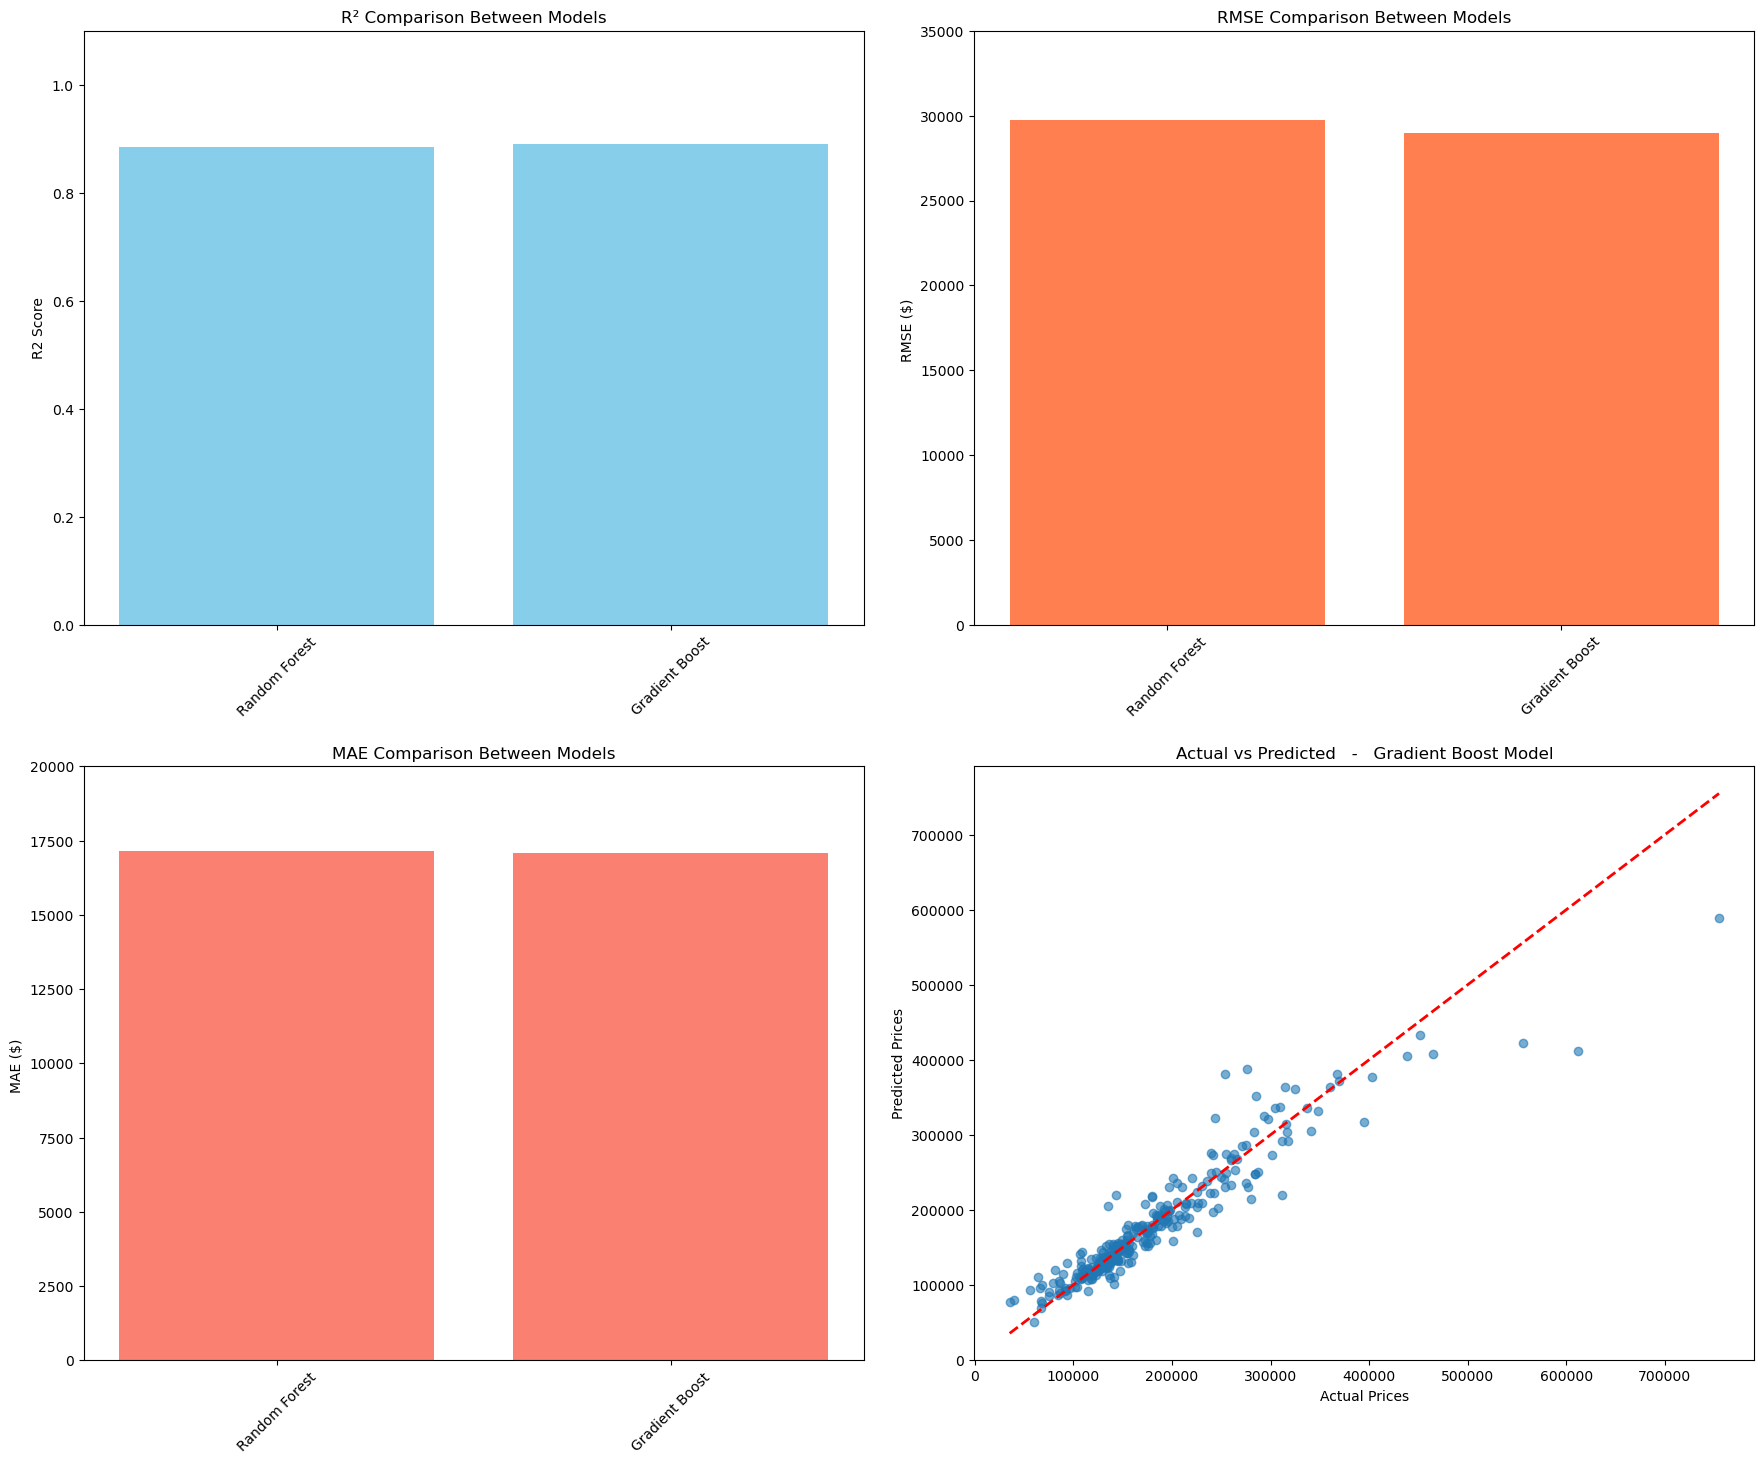

In [91]:
# R2 Graph
plt.figure(figsize=(18,15))
plt.subplot(2,2,1)
plt.bar(model_name, r2_scores, color = 'skyblue')
plt.title('R² Comparison Between Models')
plt.ylim(0, 1.1)
# plt.xlabel('Model')
plt.ylabel('R2 Score')

plt.xticks(rotation = 45)

# RMSE Graph
plt.subplot(2,2,2)
plt.bar(model_name, rmse_scores, color = 'coral')
plt.title('RMSE Comparison Between Models')
plt.ylim(0, 35000)
# plt.xlabel('Model')
plt.ylabel('RMSE ($) ')
plt.xticks(rotation = 45)


# MAE Graph
plt.subplot(2,2,3)
plt.bar(model_name, mae_scores, color = 'salmon')
plt.title('MAE Comparison Between Models')
plt.ylim(0, 20000)
# plt.xlabel('Model')
plt.ylabel('MAE ($) ')
plt.xticks(rotation = 45)


# Actual vs Predicted Price of SalePrice
plt.subplot(2,2,4)
plt.scatter(y_test, y_pred_gb, alpha=0.6)
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()] , 'r--', lw=2)
plt.title('Actual vs Predicted   -   Gradient Boost Model')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.tight_layout(pad = 2)
plt.show()

### Model Evaluation

In [92]:
print(f' ---------- Final Model Evaluation ----------\n \n')
print(f'\n Best Model :  Gradient Boost')

print(f'\n ---------- Model Performance ---------- ')
print(f'R2 Score : {r2_gb*100:.2f} %')
print(f'RMSE     : ${rmse_gb :.2f}')
print(f'MAE      : ${mae_gb:.2f}')




 ---------- Final Model Evaluation ----------
 


 Best Model :  Gradient Boost

 ---------- Model Performance ---------- 
R2 Score : 89.06 %
RMSE     : $28963.88
MAE      : $17093.81


### Residual Analysis

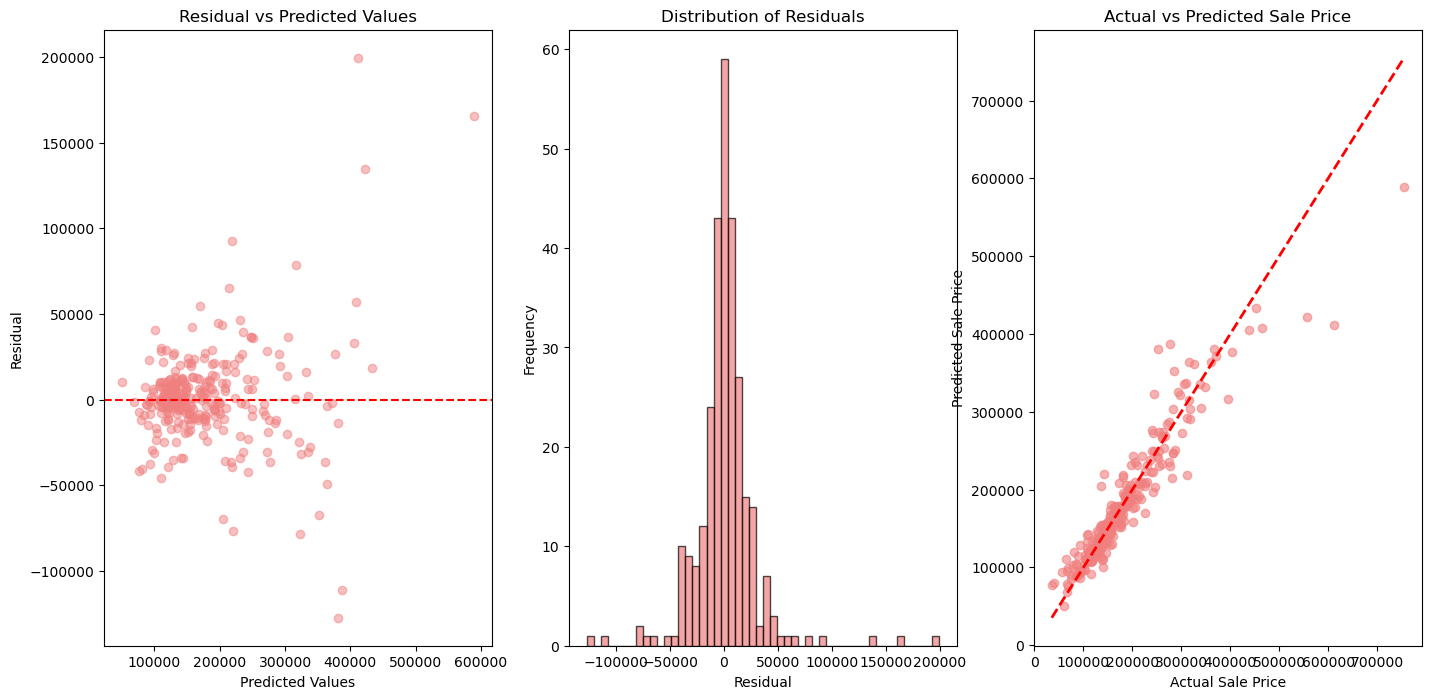

In [93]:
residual = y_test - y_pred_gb

plt.figure(figsize=(17,8))

plt.subplot(1,3,1)
plt.scatter(y_pred_gb, residual, alpha=0.5, color = 'lightcoral')
plt.axhline( y =0, color ='red', linestyle = '--')
plt.title('Residual vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residual')


plt.subplot(1,3,2)
plt.hist(residual, bins = 50, edgecolor = 'black', alpha=0.7, color = 'lightcoral')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_gb, alpha=0.6, color = 'lightcoral')
plt.plot([y_test.min(),y_test.max()], [y_test.min(),y_test.max()] , 'r--', lw=2)
plt.title('Actual vs Predicted Sale Price')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')

# plt.tight_layout()
plt.show()

### Model Fine Tunning using GridSearchCV on Random Forest

In [94]:
from sklearn.model_selection import GridSearchCV

In [95]:
param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth' : [10, 20, None],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [1,2,4]
}

In [96]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv = 5,
    scoring='r2',
    n_jobs= - 1,
    verbose = 1,
    return_train_score=True
)

grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='r2', verbose=1)

In [97]:



print(f'Best parameters: {grid_search.best_params_}')
print(f'\nBest Croos-Validation R2 : {grid_search.best_score_:.4f}')

best_model_grid = grid_search.best_estimator_
print(f'\nBest Model : {best_model_grid}')



Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Croos-Validation R2 : 0.8591

Best Model : RandomForestRegressor(max_depth=20, random_state=42)


In [98]:
result_data = pd.DataFrame(grid_search.cv_results_)

In [99]:
result_data.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,1.439052,0.031106,0.008137,0.003376,10,1,2,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.909154,0.817940,0.841640,0.838380,0.877557,0.856934,0.032407,17,0.972994,0.976756,0.976416,0.977783,0.976608,0.976111,0.001629
1,2.676699,0.178222,0.016883,0.006883,10,1,2,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.912606,0.816589,0.840134,0.837273,0.877114,0.856743,0.034067,23,0.973994,0.978341,0.976377,0.977296,0.976908,0.976583,0.001446
2,3.126572,0.224899,0.018394,0.007521,10,1,2,300,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.905689,0.816369,0.839519,0.839182,0.881691,0.856490,0.032413,27,0.973657,0.978379,0.976091,0.977504,0.977092,0.976545,0.001620
3,0.854947,0.067771,0.006605,0.002973,10,1,5,100,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.904404,0.824100,0.832969,0.843579,0.873668,0.855744,0.029520,30,0.965993,0.970301,0.971793,0.972387,0.970330,0.970161,0.002238
4,1.743267,0.042919,0.010390,0.002308,10,1,5,200,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_...",0.906192,0.820419,0.835349,0.840028,0.874958,0.855389,0.031063,33,0.967347,0.971103,0.971321,0.971395,0.970423,0.970318,0.001524


In [100]:
top_5 = result_data.nlargest(5, 'mean_test_score') [['mean_test_score', 'std_test_score','params']]

print(top_5)

    mean_test_score  std_test_score  \
27         0.859052        0.031903   
54         0.859000        0.031091   
28         0.858726        0.031880   
55         0.858370        0.032301   
67         0.858287        0.030764   

                                               params  
27  {'max_depth': 20, 'min_samples_leaf': 1, 'min_...  
54  {'max_depth': None, 'min_samples_leaf': 1, 'mi...  
28  {'max_depth': 20, 'min_samples_leaf': 1, 'min_...  
55  {'max_depth': None, 'min_samples_leaf': 1, 'mi...  
67  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  


In [101]:
default_model_rf = RandomForestRegressor(random_state=42)

In [102]:
default_model_rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [103]:
y_pred_default_rf = default_model_rf.predict(x_test)
default_r2 = r2_score(y_test, y_pred_default_rf)

In [104]:
r2_tuned = r2_score(y_test, y_pred_rf)

print(f'\n Improvement of model')
print(f'\n Default R2 : {default_r2:.4f}')
print(f'\n Tunned R2 : {r2_tuned:.4f}')
print(f'\n Improvement : {r2_tuned - default_r2:.4f}')


 Improvement of model

 Default R2 : 0.8848

 Tunned R2 : 0.8848

 Improvement : 0.0000


### Evaluate Tunning Tunning 

### Saving model in local file.

In [105]:
# saving model without tunning ,

import joblib

joblib.dump(model_gb, 'house_price_pred_model_gb.pkl')

best_params = grid_search.best_params_
print(f' best parameter :{best_params}')

 best parameter :{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [106]:
# make final prediction


final_prediction = model_gb.predict(x_test)

result_data = pd.DataFrame({
    'Actual_Price': (y_test),
    'Predicted_Price': (final_prediction),
    'Error': (y_test) - (final_prediction)
})

print(result_data.head(10))
print(f' Prediction Results')
print(f" Average Error: ${result_data['Error'].abs().mean():,.2f}")

print(f"Accuracy %: {(abs(result_data['Error']/result_data['Actual_Price']) < 0.1).mean():.1%}")

      Actual_Price  Predicted_Price         Error
892         154500    142166.388692  12333.611308
1105        325000    361492.079491 -36492.079491
413         115000    118239.393732  -3239.393732
522         159000    151683.934872   7316.065128
1036        315500    315008.238837    491.761163
614          75500     84657.812756  -9157.812756
218         311500    219190.420803  92309.579197
1160        146000    143264.143426   2735.856574
649          84500     87019.985225  -2519.985225
887         135500    132332.249679   3167.750321
 Prediction Results
 Average Error: $17,093.81
Accuracy %: 69.9%


### Make Prediction 

In [112]:
def prepare_features(quality, area, basement, garage, year):
    feature={}
    feature['OverallQual']= quality
    feature['GrLivArea'] = area
    feature['TotalBsmtSF'] = basement
    feature['GarageCars'] = garage
    feature['YearBuilt'] = year

    for i in x_train.columns:
        if i not in feature:
            feature[i] = x_train[i].median()

    return pd.DataFrame([feature])[x_train.columns]


new_house_data = prepare_features(9,5000,800,2,2000)
# print(f'Feature prepared : {new_house_data.shape}')

predicted_price = model_gb.predict(new_house_data)
print(f' Predicted price by model : ${(predicted_price[0]):.2f}')

 Predicted price by model : $234201.68


In [108]:
feature_import = pd.DataFrame({
    'feature': x_train.columns,
    'important': model_gb.feature_importances_
}).sort_values('important', ascending=False)


print(f'\n top 10 features from best model:')
print(feature_import.head(10))


 top 10 features from best model:
         feature  important
15   OverallQual   0.407415
77  TotalSurface   0.331574
32    BsmtFinSF1   0.029451
59    GarageCars   0.027585
28      BsmtQual   0.017239
42      2ndFlrSF   0.016603
44     GrLivArea   0.016087
75      HouseAge   0.015294
58  GarageFinish   0.012381
17     YearBuilt   0.011373


In [110]:
# CREATE PREPROCESSING INFO (Add this after Part 7, before saving models)
print("\n CREATING PREPROCESSING INFORMATION...")



# Create preprocessing information
preprocessing_info = {
    'feature_names': list(x_train.columns),
    'label_encoders': label_encoder,
    'best_model': 'Gradient Boosting',
    'r2_score': r2_gb,  # Your R² score variable
    'model_trained_on': 'Gradient Boosting only'
}

# Save it
joblib.dump(preprocessing_info, 'models/preprocessing_info.pkl')
print(" preprocessing_info.pkl created and saved!")
print(f"Contains: {list(preprocessing_info.keys())}")


 CREATING PREPROCESSING INFORMATION...
 preprocessing_info.pkl created and saved!
Contains: ['feature_names', 'label_encoders', 'best_model', 'r2_score', 'model_trained_on']


### Prediction

OverQual - 9

GrLivArea - 1500

TotalBsmt - 800

Garage - 2

Year Build - 2000


Predicted price ~ $234,201.68

Summary
----------

1. After training and evaluating mutliple machine learning models on the house price dataset, **Gradient Boosting** emerges as the best performing model for this house price prediction project and **R2 score of Gradient Boosting 88% after tunning achieve R2 score of 91%**

2. In this Gradient Boost model construction quality matter most, sometime area (sqft) is also key determinant to consumer.

3. In America house hold every family own car which is used to travel to every part of store, so parking facilty is also consider 

4. Price of house varies based on  ~

**living area(GrLivArea), Quality of house (OverallQual), basement area (TotalBsmtArea), Garage for car (Garage), and Year Built(YearBuilt)**

### Suggestion to customer to buy the house

* OverallQaulity ~ 8
* Space ~ 2400+ sqft
* Bathroom ~ 3+
* Garage size ~ 3+
* Kitchen space ~ 500+
* Utility space ~ 500
* Budget should be ~ $ 150,000 -  250,000